# Softmax Activation Function in Neural Networks

In Deep Learning, activation functions are important because they introduce non-linearity into neural networks allowing them to learn complex patterns. Softmax Activation Function transforms a vector of numbers into a probability distribution, where each value represents the likelihood of a particular class. It is especially important for multi-class classification problems.

Each output value lies between 0 and 1.
The sum of all output values equals 1.

tep-By-Step Implementation
Step 1: Import Necessary Libraries
Import NumPy for numerical operations
TensorFlow and Keras to build and train the neural network
Use Matplotlib for visualizing training accuracy and loss.

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

Step 2: Load and Prepare the Dataset
Load the Iris dataset multi-class classification dataset.
Extract features and labels from the dataset.
Convert labels to one-hot encoded format for softmax based training.
Split the data into training and testing sets for evaluation.

In [2]:
iris = load_iris()
X = iris.data  # Features
y = iris.target

In [3]:
y_encoded = to_categorical(y)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)


Step 3: Neural Network Model
Sequential to create a simple feedforward neural network.
The hidden layer uses ReLU activation to learn non linear patterns.
The output layer uses Softmax activation to produce class probabilities.

In [5]:
model = Sequential([
    Dense(8, input_shape=(4,), activation='relu'),
    Dense(3, activation='softmax')
])

C:\Users\skhan2\AppData\Local\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Step 4: Compile the Model
Define Adam optimizer for efficient gradient updates.
categorical_crossentropy as the loss function for multi-class problems.
Compiling prepares the model for training.

In [6]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

Step 5: Train the Model
Train the model using the training dataset.
Run for 100 epochs with a small batch size for better learning.
Use validation_split=0.2 to monitor overfitting during training.
The history object stores loss and accuracy data for visualization

In [7]:
history = model.fit(X_train, y_train, epochs=100, batch_size=8, validation_split=0.2, verbose=0)

# Step 6: Evaluate the Model
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Step 7: Predict and Display Probabilities
sample = np.array([[5.1, 3.5, 1.4, 0.2]])  # Example flower features
prediction = model.predict(sample)
predicted_class = np.argmax(prediction)

Test Accuracy: 80.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


Step 6: Predict and Display Probabilities
Use the trained model to predict class probabilities via Softmax.
Determine the predicted class with the highest probability.
Display both predicted probabilities and the corresponding class name.

In [8]:

print("\nPredicted Probabilities (Softmax Output):", prediction)
print("Predicted Class:", iris.target_names[predicted_class])


Predicted Probabilities (Softmax Output): [[0.6576048  0.19255342 0.14984182]]
Predicted Class: setosa


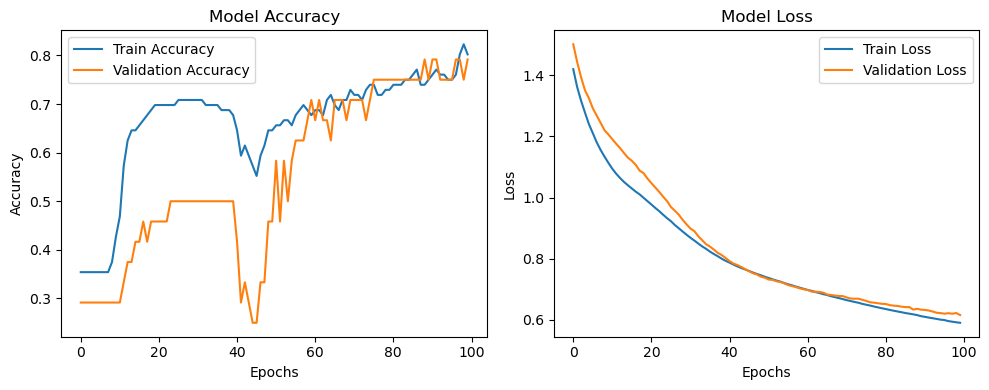

In [9]:
plt.figure(figsize=(10,4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

Why Use Softmax in the Last Layer
The Softmax Activation function is typically used in the final layer of a classification neural network because:

It transforms the model raw output into interpretable probabilities.
It ensures the outputs are mutually exclusive suitable for problems where each sample belongs to exactly one class.
It works seamlessly with the Cross Entropy Loss Function which measures the difference between predicted and actual probabilities.
Applications
Neural Networks: Used in the output layer of models like CNNs or MLPs for multi-class classification.
Attention Mechanisms: Assigns attention weights to different tokens or words, normalizing them to sum to 1.
Reinforcement Learning: Converts Q values or action values into probabilities for stochastic action selection.
Model Ensembles: Combines multiple model predictions into a single probabilistic output.
Challenges
Overconfidence: Tends to produce extremely confident predictions even for uncertain inputs.
Sensitivity to Outliers: Small variations in logits can cause large shifts in probability outputs.
Softmax Bottleneck: Limited ability to model complex relationships between output classes.
Poor Calibration: Predicted probabilities often do not align with true likelihoods.
Gradient Saturation: Can cause vanishing gradients when one class probability dominates others.